<a href="https://colab.research.google.com/github/dineshxo/Productivity_Research_Analysis/blob/main/Productivity_Research_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Table 4.4: Model Comparison Results
          Algorithm  Accuracy (%)  F1-Score (Macro)
  Gradient Boosting     78.207381          0.610205
      Random Forest     78.558875          0.584556
      Decision Tree     71.177504          0.549140
Logistic Regression     73.110721          0.443741


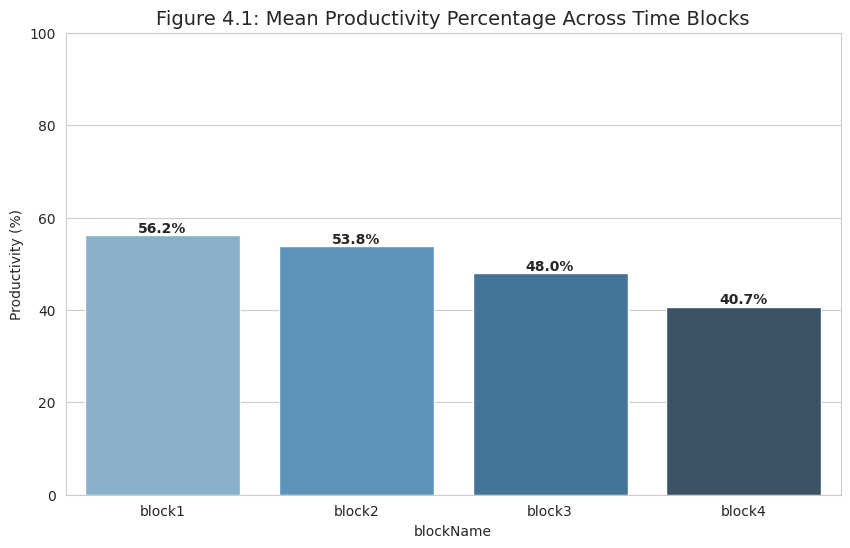

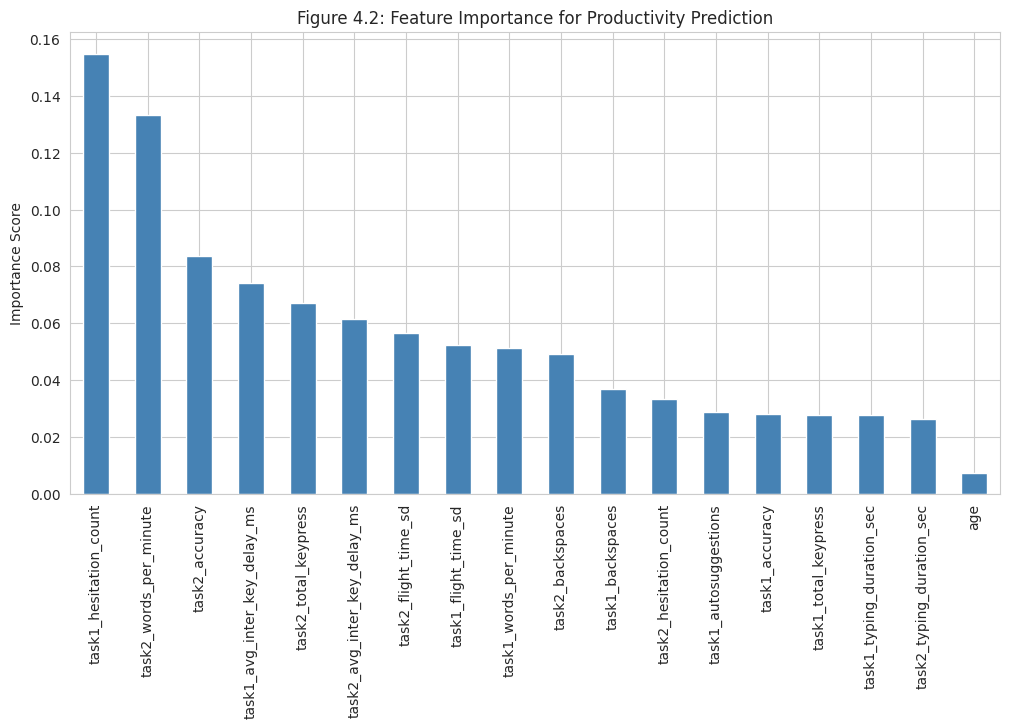

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
df = pd.read_csv('grand_master_dataset.csv')

# 2. Labeling Logic
def categorize_productivity(score):
    if score < 40: return 0 # Low
    elif score < 70: return 1 # Medium
    else: return 2 # High

df['productivityClass'] = df['productivityPercentage'].apply(categorize_productivity)

# 3. Features for Machine Learning (19 behavioral metrics)
features = [
    'task1_words_per_minute', 'task1_accuracy', 'task1_avg_inter_key_delay_ms',
    'task1_typing_duration_sec', 'task1_backspaces', 'task1_autosuggestions',
    'task1_total_keypress', 'task1_flight_time_sd', 'task1_hesitation_count',
    'task2_words_per_minute', 'task2_accuracy', 'task2_avg_inter_key_delay_ms',
    'task2_typing_duration_sec', 'task2_backspaces', 'task2_total_keypress',
    'task2_flight_time_sd', 'task2_hesitation_count', 'age'
]

X = df[features]
y = df['productivityClass']

# 4. Model Comparison (RQ1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Algorithm": name,
        "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    })

comparison_df = pd.DataFrame(results).sort_values(by="F1-Score (Macro)", ascending=False)
print("Table 4.4: Model Comparison Results")
print(comparison_df.to_string(index=False))

# 5. Graph: Productivity Variation (RQ5)
block_order = ['block1', 'block2', 'block3', 'block4']
avg_prod = df.groupby('blockName')['productivityPercentage'].mean().reindex(block_order)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=avg_prod.index, y=avg_prod.values, palette='Blues_d')
plt.title('Figure 4.1: Mean Productivity Percentage Across Time Blocks', fontsize=14)
plt.ylabel('Productivity (%)')
plt.ylim(0, 100)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontweight='bold')
plt.show()

# 6. Feature Importance (RQ2)
best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Figure 4.2: Feature Importance for Productivity Prediction')
plt.ylabel('Importance Score')
plt.show()